# Header: Measuring vertical electric field (version 1)

This notebook is used to exploit empymod for quick studies around measuring the vertical electric field component for a shallow conductive anomaly (~150 m), and comparing this against horizontal component measurement.

*Contents:*

**Simple anomaly model**
- 1. Source field for different source components in a uniform halfspace & the field response to a 1d layer anomaly & difference
- 2. The effect of the source length on this source field - only computed for uniform (baseline) scenario
- 3. The effect of frequency on the resolution of an anomaly - baseline/anomaly/difference responses are computed as well as receiver line responses
- 4. The effect of receiver length - the field is computed with dense spatial sampling, and then the effect of selecting different receiver amounts on receiver line responses is shown

**Complex anomaly models**
- 1. Anomaly characteristics are varied (thickness, internal heterogeneity, anomaly contrast) and the effect is shown on measured fields and receiver lines

Remaining questions
- how do responses change for a capacitively coupled receiver?

# Code

In [ ]:
import emg3d
import empymod
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
from Emg3d_extra_grid_functions import * #See note in next cell

plt.style.use('bmh')

# Comment this out on Google Colab
#%matplotlib widget

## Functions

In [ ]:
def manual_yz_slice_3x(titles, efield1, efield2, efield3, y_extent=300, zmin=-250, zmax=0, size_y = 6.4, size_z = 4.8, vmin = 1e-8, vmax = 1e-4):

    fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(15,5))

    ax1_plot = ax1.imshow(np.abs(efield1), extent = [0, size_y, 0, size_z], norm='log', vmin = vmin, vmax = vmax)
    ax1.set_title(titles[0])
    ax1.set_xlabel('y (m)')
    ax1.set_ylabel('z (m)')
    plt.colorbar(ax1_plot, location='bottom')
    ax1.set_xticks(np.arange(0, size_y, size_y/4), np.arange(-y_extent, y_extent, y_extent/2))
    ax1.set_yticks(np.arange(0, size_z, size_z/4), np.arange(zmin, zmax, (zmax-zmin)/4))
    ax1.grid(False)
    
    ax2_plot = ax2.imshow(np.abs(efield2), extent = [0, size_y, 0, size_z], norm='log', vmin = vmin, vmax = vmax)
    ax2.set_title(titles[1])
    ax2.set_xlabel('y (m)')
    ax2.set_ylabel('z (m)')
    plt.colorbar(ax2_plot, location='bottom')
    ax2.set_xticks(np.arange(0, size_y, size_y/4), np.arange(-y_extent, y_extent, y_extent/2))
    ax2.set_yticks(np.arange(0, size_z, size_z/4), np.arange(zmin, zmax, (zmax-zmin)/4))
    ax2.grid(False)
    
    ax3_plot = ax3.imshow(np.abs(efield3), extent = [0, size_y, 0, size_z], norm='log', vmin = vmin, vmax = vmax)
    ax3.set_title(titles[2])
    ax3.set_xlabel('y (m)')
    ax3.set_ylabel('z (m)')
    plt.colorbar(ax3_plot, location='bottom')
    ax3.set_xticks(np.arange(0, size_y, size_y/4), np.arange(-y_extent, y_extent, y_extent/2))
    ax3.set_yticks(np.arange(0, size_z, size_z/4), np.arange(zmin, zmax, (zmax-zmin)/4))
    ax3.grid(False)

In [ ]:
def manual_xyz_slice_9x(title, efield1, efield2, efield3, ix = 0, iy = 0, iz = 0, xmin=-300, xmax=300, ymin=-300, ymax=300, zmin=-250, zmax=0, vmin = 1e-8, vmax = 1e-4):

    fig, ((ax1, ax2, ax3), (ax4, ax5, ax6), (ax7, ax8, ax9)) = plt.subplots(3,3, figsize=(15,15), tight_layout=True)
    fig.suptitle(title)
    axes = [ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9]
    efields = [efield1, efield2, efield3]

    sizexy = 6.4
    sizez = 4.8
    
    for i in np.arange(len(efields)):
        ax_a = axes[i*3]
        ax_b = axes[i*3+1]
        ax_c = axes[i*3+2]
        fielda, fieldb, fieldc = np.abs(np.transpose(efields[i][ix,:,:])), np.abs(np.transpose(efields[i][:,iy,:])), np.abs(np.transpose(efields[i][:,:,iz]))
        plot_a = ax_a.imshow(fielda, extent = [0, sizexy, 0, sizez], norm='log', vmin = vmin, vmax = vmax)
        #ax_a.contour(fielda, [np.max(fielda)/np.e], colors='pink', origin = 'upper', extent = [0, sizexy, 0, sizez])
        plot_b = ax_b.imshow(fieldb, extent = [0, sizexy, 0, sizez], norm='log', vmin = vmin, vmax = vmax)
        #ax_b.contour(fieldb, [np.max(fieldb)/np.e], colors='pink', origin = 'upper', extent = [0, sizexy, 0, sizez])
        plot_c = ax_c.imshow(fieldc, extent = [0, sizexy, 0, sizexy], norm='log', vmin = vmin, vmax = vmax)
        #ax_c.contour(fieldc, [np.max(fieldc)/np.e], colors='pink', origin = 'lower', extent = [0, sizexy, 0, sizez])
        for ax in [ax_a, ax_b, ax_c]:
            ax.set_title('Field '+str(i+1)+' (V/m)')
            ax.grid(False)
        for ax_plot in [plot_a, plot_b, plot_c]:
            plt.colorbar(ax_plot, location='bottom')
        ax_a.set_xticks(np.arange(0, sizexy, sizexy/4), np.arange(ymin, ymax, (ymax-ymin)/4))
        ax_a.set_yticks(np.arange(0, sizez, sizez/4), np.arange(zmin, zmax, (zmax-zmin)/4))
        ax_a.set_xlabel('y (m)')
        ax_a.set_ylabel('z (m)')
        ax_b.set_xticks(np.arange(0, sizexy, sizexy/4), np.arange(xmin, xmax, (xmax-xmin)/4))
        ax_b.set_yticks(np.arange(0, sizez, sizez/4), np.arange(zmin, zmax, (zmax-zmin)/4))
        ax_b.set_xlabel('x (m)')
        ax_b.set_ylabel('z (m)')
        ax_c.set_xticks(np.arange(0, sizexy, sizexy/4), np.arange(xmin, xmax, (xmax-xmin)/4))
        ax_c.set_yticks(np.arange(0, sizexy, sizexy/4), np.arange(ymin, ymax, (ymax-ymin)/4))
        ax_c.set_xlabel('x (m)')
        ax_c.set_ylabel('y (m)')

In [387]:
def manual_xz_slice_9x(title, efields, names = [1,2,3,4,5,6,7,8,9], iz = 0, xmin=-300, xmax=300, zmin=-250, zmax=0, vmin = 1e-8, vmax = 1e-4):

    fig, ((ax1, ax2, ax3), (ax4, ax5, ax6), (ax7, ax8, ax9)) = plt.subplots(3,3, figsize=(15,15), tight_layout=True)
    fig.suptitle(title)
    axes = [ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9]

    sizexy = 6.4
    sizez = 4.8
    
    for i in np.arange(len(axes)):
        ax = axes[i]
        to_plot = np.abs(efields[i]) #Assuming field objects are already the right dimensions
        plot = ax.imshow(to_plot, extent = [0, sizexy, 0, sizez], norm='log', vmin = vmin, vmax = vmax)
        #ax.contour(to_plot, [contour[i]], colors='pink', origin = 'upper', extent = [0, sizexy, 0, sizez])
        ax.set_title('Field '+str(names[i])+' (V/m)')
        ax.grid(False)
        plt.colorbar(plot, location='bottom')
        ax.set_xticks(np.arange(0, sizexy, sizexy/4), np.arange(xmin, xmax, (xmax-xmin)/4))
        ax.set_yticks(np.arange(0, sizez, sizez/4), np.arange(zmin, zmax, (zmax-zmin)/4))
        ax.set_xlabel('x (m)')
        ax.set_ylabel('z (m)')

In [268]:
def manual_xz_slice_3x(title, efields, names = [1,2,3], iz = 0, xmin=-300, xmax=300, zmin=-250, zmax=0, vmin = 1e-8, vmax = 1e-4):

    fig, ((ax1, ax2, ax3)) = plt.subplots(1,3, figsize=(15,5), tight_layout=True)
    fig.suptitle(title)
    axes = [ax1, ax2, ax3]

    sizexy = 6.4
    sizez = 4.8
    
    for i in np.arange(len(efields)):
        ax = axes[i]
        to_plot = np.abs(efields[i]) #Assuming field objects are already the right dimensions
        plot = ax.imshow(to_plot, extent = [0, sizexy, 0, sizez], norm='log', vmin = vmin, vmax = vmax)
        ax.set_title('Field '+str(names[i])+' (V/m)')
        ax.grid(False)
        plt.colorbar(plot, location='bottom')
        ax.set_xticks(np.arange(0, sizexy, sizexy/4), np.arange(xmin, xmax, (xmax-xmin)/4))
        ax.set_yticks(np.arange(0, sizez, sizez/4), np.arange(zmin, zmax, (zmax-zmin)/4))
        ax.set_xlabel('x (m)')
        ax.set_ylabel('z (m)')

# Tests on simple anomaly model

## 1. Source field for different sources & frequencies

see also: https://empymod.emsig.xyz/en/stable/gallery/fdomain/src_rec_comparison.html

How does the source field look for a uniform halfspace? we simulate x-, y- and z-directed source at the origin, assuming a perfect infinitessimal dipole source

In [ ]:
#Specify which component of the receivers and which frequency range we want to test for

component = 'Ez'
frequencies = [10, 1000, 10000]

if component == 'Ez':
    pab = [31, 32, 33]
elif component == 'Ey':
    pab = [21, 22, 23]
elif component == 'Ex':
    pab = [11, 12, 13]

sources = ['x-dir', 'y-dir', 'z-dir']

In [ ]:
#Create a 1D subsurface model to test with

# Layer boundaries
depth = [0, 150, 170]

# Layer resistivities in Ohm.m
res_base = np.array([1e8, 35, 35, 35]) # incl. air (lower res, because of 3D modelling)
res_anomaly = np.array([1e8, 35, 13, 35])

In [ ]:
#Specify domain in which to compute the EM response (symmetric in x,y)

x = np.arange(-250,260,10)
rx = np.tile(x[:, None], x.size)
ry = rx.transpose()

z = np.arange(0, 260,10)

In [174]:
base_solutions1 = {}
anom_solutions1 = {}
diff_solutions1 = {}

for i in np.arange(len(frequencies)):
    freq = frequencies[i]
    for j in np.arange(len(pab)):
        ab = pab[j]
        source = sources[j]

        solutions = []
        for res in [res_base, res_anomaly]:

            emp_solution = np.zeros((len(rx), len(ry), len(z)), dtype = complex)
            for m in np.arange(len(z)):
                inp = {
                    'src': [0, 0, 0],
                    'rec': [rx.ravel(), ry.ravel(), z[m]],
                    'depth': depth,
                    'res': res,
                    'freqtime': freq,
                    'verb': 0,
                }
                efield = empymod.dipole(ab=ab, **inp).reshape(rx.shape).amp()
                emp_solution[:,:,m] = efield
            solutions.append(emp_solution)
                    
        base_solutions1[component+' for source: '+source+' and freq: '+str(freq)+' Hz'] = solutions[0]
        anom_solutions1[component+' for source: '+source+' and freq: '+str(freq)+' Hz'] = solutions[1]
        diff_solutions1[component+' for source: '+source+' and freq: '+str(freq)+' Hz'] = solutions[1]-solutions[0]

In [175]:
# what to plot

to_plot = 'base'
ifr = 2
print('frequency: '+str(frequencies[ifr])+' Hz')

if to_plot == 'base':
    emp_solution = base_solutions1
elif to_plot == 'anom':
    emp_solution = anom_solutions1
elif to_plot == 'diff':
    emp_solution = diff_solutions1

frequency: 10000 Hz


x plane:  0
y plane:  0
z plane:  0


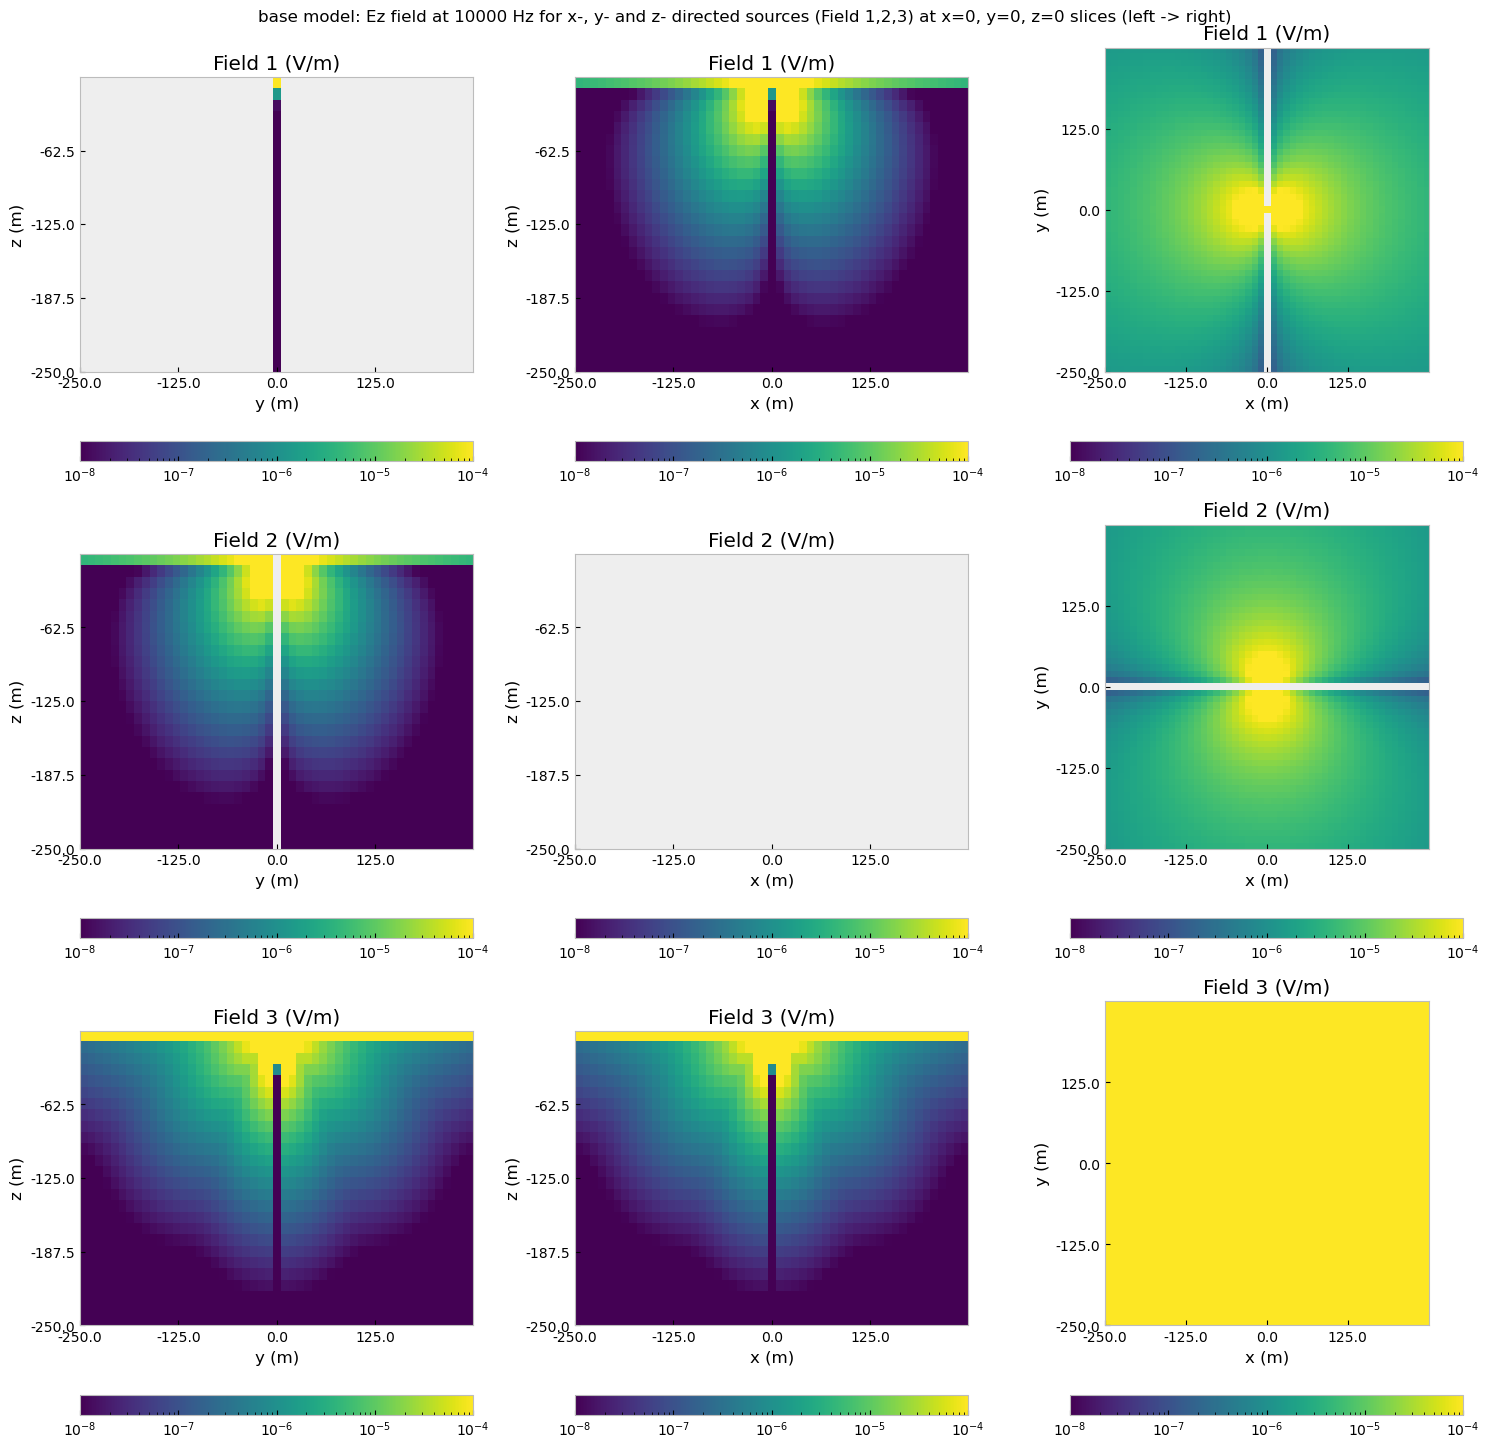

In [176]:
#Plot E fields

keys = list(base_solutions1.keys())

ix = 25
iy = 25
iz = 0

print('x plane: ', rx[:,0][ix])
print('y plane: ', ry[0][iy])
print('z plane: ', -z[iz])

efield1 = emp_solution[keys[ifr*3+0]]
efield2 = emp_solution[keys[ifr*3+1]]
efield3 = emp_solution[keys[ifr*3+2]]

title = to_plot+' model: '+component+' field at '+str(frequencies[ifr])+' Hz for x-, y- and z- directed sources (Field 1,2,3) at x='+str(rx[:,0][ix])+', y='+str(ry[0][iy])+', z='+str(z[iz])+' slices (left -> right)'

manual_xyz_slice_9x(title, efield1, efield2, efield3, ix = ix, iy = iy, iz = iz, xmin=rx[:,0][0], xmax=rx[:,0][-1], ymin=ry[0][0], ymax=ry[0][-1], zmin=-z[-1], zmax=z[0], vmin = 1e-8, vmax = 1e-4)

#manual_plot_slice_3x(efield1, efield2, efield3, y_extent=-300, zmin=-250, zmax=0, size_y = 6.4, size_z = 4.8, vmin = 1e-6, vmax = 1e1)

In [177]:
efield1 = emp_solutions[keys[ifr*3+0]]
efield2 = emp_solutions[keys[ifr*3+1]]
efield3 = emp_solutions[keys[ifr*3+2]]

manual_plot_Zslice2_3x(efield1, efield2, efield3, ymin = -300, ymax = 300, xmin = -300, xmax = 300, size_y = 6.4, size_x = 6.4, z_slice = 0, vmin = 1e-8, vmax = 1e-4)

NameError: name 'emp_solutions' is not defined

## 2. Effect of source length

In [311]:
#Specify which component of the receivers and which frequency range we want to test for

component = 'Ez'
frequencies = [1000]

if component == 'Ez':
    az = 0
    dip = 90
elif component == 'Ey':
    az = 90
    dip = 0
elif component == 'Ex':
    az = 0
    dip = 0

sources = ['x-dir', 'y-dir', 'z-dir']

# Testing different lengths
lengths_to_test = [10, 50, 100]
source_coords = []
for i in np.arange(len(lengths_to_test)):
    for j in np.arange(3):
        source_adapt = np.array([0,0,0,0,0,0])
        print(j*2)
        source_adapt[j*2] = -lengths_to_test[i]
        source_coords.append(source_adapt)

0
2
4
0
2
4
0
2
4


In [312]:
#Create a 1D subsurface model to test with

# Layer boundaries
depth = [0, 150, 170]

# Layer resistivities in Ohm.m
res_base = np.array([1e8, 35, 35, 35]) # incl. air (lower res, because of 3D modelling)

In [313]:
print(len(source_coords))
print(source_coords)

9
[array([-10,   0,   0,   0,   0,   0]), array([  0,   0, -10,   0,   0,   0]), array([  0,   0,   0,   0, -10,   0]), array([-50,   0,   0,   0,   0,   0]), array([  0,   0, -50,   0,   0,   0]), array([  0,   0,   0,   0, -50,   0]), array([-100,    0,    0,    0,    0,    0]), array([   0,    0, -100,    0,    0,    0]), array([   0,    0,    0,    0, -100,    0])]


In [314]:
#Specify domain in which to compute the EM response (symmetric in x,y)

x = np.arange(-250,260,10)
rx = np.tile(x[:, None], x.size)
ry = rx.transpose()

z = np.arange(0, 260,10)

In [315]:
base_solutions2 = {}

for i in np.arange(len(lengths_to_test)):
    freq = frequencies[0]

    for j in np.arange(3):
        source = sources[j]
        src_coord = source_coords[i*len(lengths_to_test)+j]

        emp_solution = np.zeros((len(rx), len(ry), len(z)), dtype = complex)
        for m in np.arange(len(z)):
            inp = {
                'src': src_coord,
                'rec': [rx.ravel(), ry.ravel(), z[m], az, dip],
                'depth': depth,
                'res': res_base,
                'freqtime': freq,
                'verb': 0,
                'srcpts': 5
            }
            efield = empymod.bipole(**inp).reshape(rx.shape).amp()
            emp_solution[:,:,m] = efield
                    
        base_solutions2[component+' for source: '+source+' and length: '+str(lengths_to_test[i])+' m'] = emp_solution

In [316]:
print(list(base_solutions2.keys()))
print(np.shape(base_solutions2[list(base_solutions2.keys())[0]]))

['Ez for source: x-dir and length: 10 m', 'Ez for source: y-dir and length: 10 m', 'Ez for source: z-dir and length: 10 m', 'Ez for source: x-dir and length: 50 m', 'Ez for source: y-dir and length: 50 m', 'Ez for source: z-dir and length: 50 m', 'Ez for source: x-dir and length: 100 m', 'Ez for source: y-dir and length: 100 m', 'Ez for source: z-dir and length: 100 m']
(51, 51, 26)


In [321]:
# what to plot

to_plot = 'base'
ilen = 0
print('Source length: '+str(lengths_to_test[ilen])+' m')

if to_plot == 'base':
    emp_solution = base_solutions2
elif to_plot == 'anom':
    emp_solution = anom_solutions2
elif to_plot == 'diff':
    emp_solution = diff_solutions2

Source length: 10 m


x plane:  0
y plane:  0
z plane:  -10


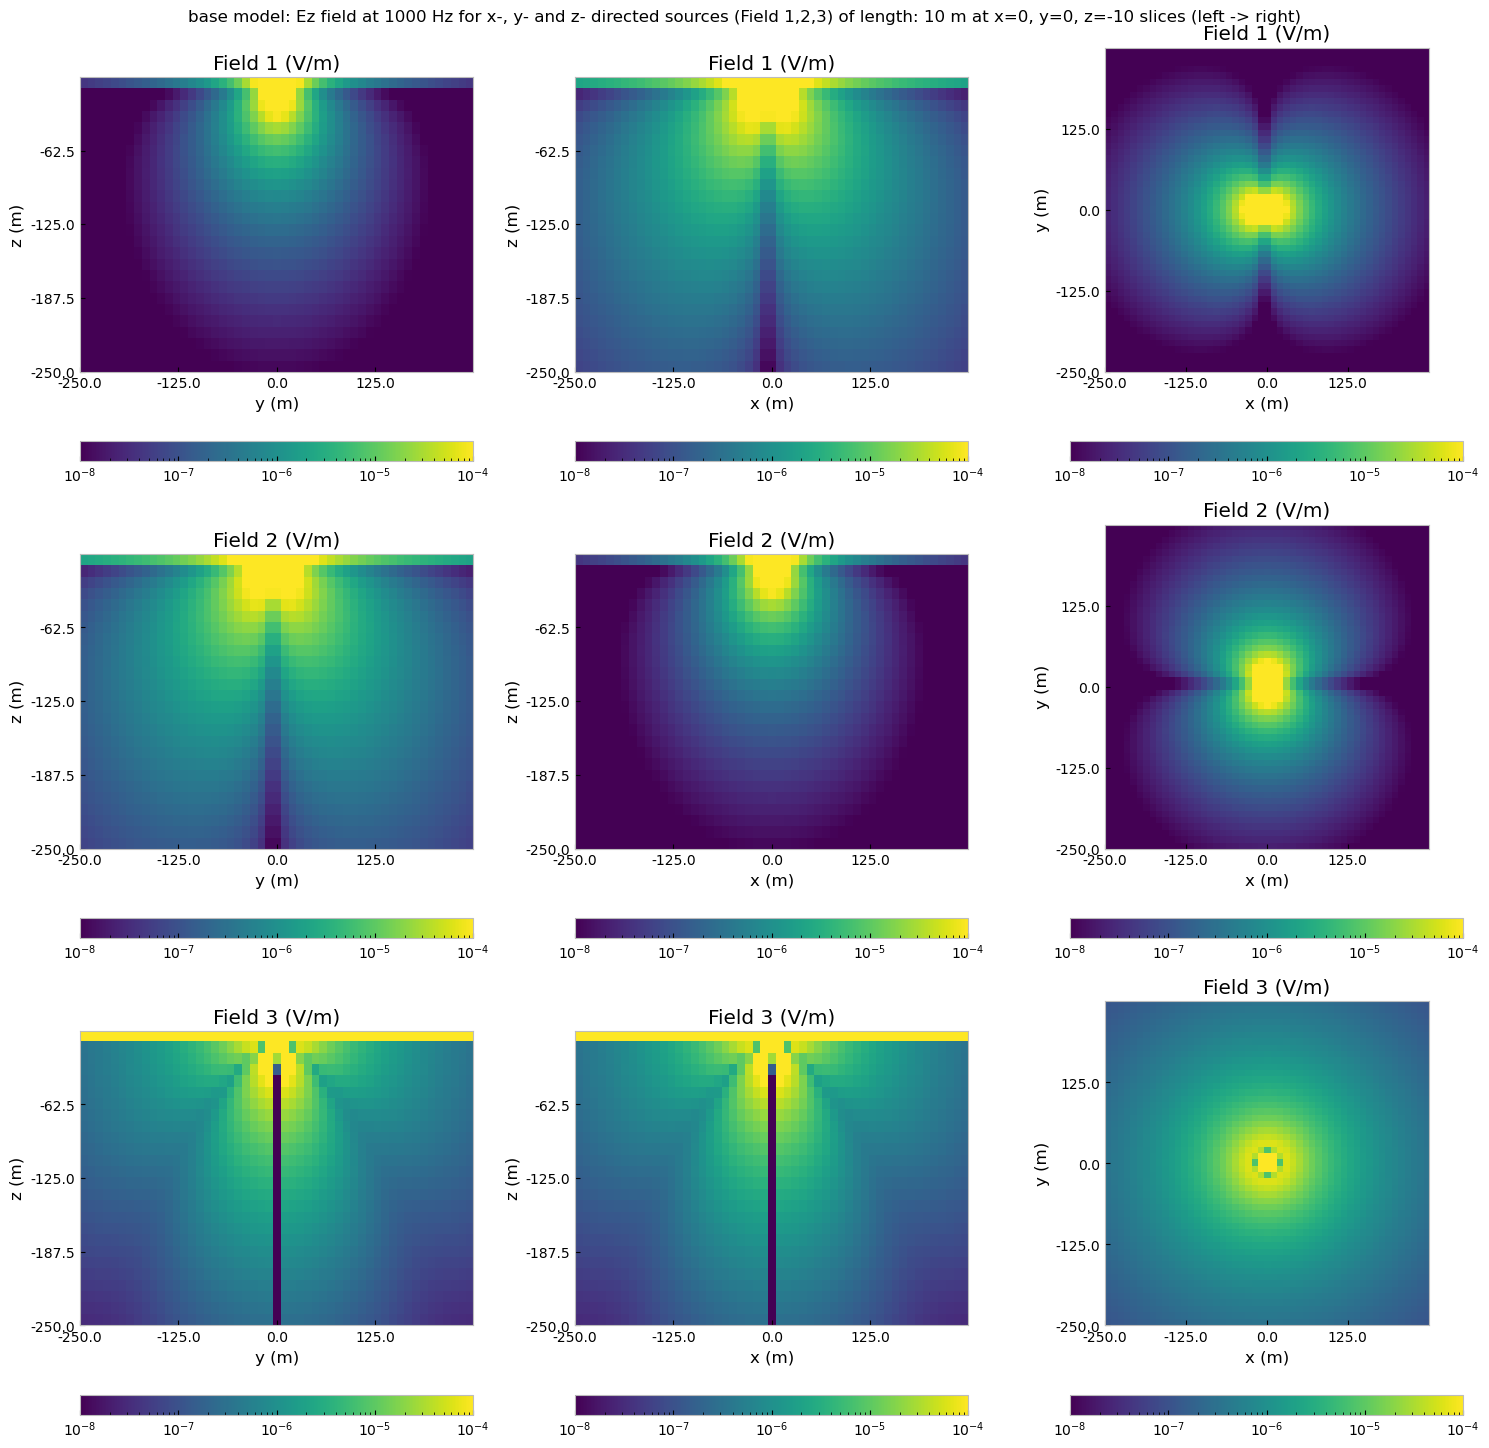

In [322]:
#Plot E fields

keys = list(emp_solution.keys())

ix = 25
iy = 25
iz = 1

print('x plane: ', rx[:,0][ix])
print('y plane: ', ry[0][iy])
print('z plane: ', -z[iz])

efield1 = emp_solution[keys[ilen*3+0]]
efield2 = emp_solution[keys[ilen*3+1]]
efield3 = emp_solution[keys[ilen*3+2]]

title = to_plot+' model: '+component+' field at '+str(frequencies[0])+' Hz for x-, y- and z- directed sources (Field 1,2,3) of length: '+str(lengths_to_test[ilen])+' m at x='+str(rx[:,0][ix])+', y='+str(ry[0][iy])+', z='+str(-z[iz])+' slices (left -> right)'

manual_xyz_slice_9x(title, efield1, efield2, efield3, ix = ix, iy = iy, iz = iz, xmin=rx[:,0][0], xmax=rx[:,0][-1], ymin=ry[0][0], ymax=ry[0][-1], zmin=-z[-1], zmax=z[0], vmin = 1e-8, vmax = 1e-4)

#manual_plot_slice_3x(efield1, efield2, efield3, y_extent=-300, zmin=-250, zmax=0, size_y = 6.4, size_z = 4.8, vmin = 1e-6, vmax = 1e1)

In [ ]:
## 

## 3. Effect of frequency

In [561]:
#Specify which component of the receivers and which frequency range we want to test for

component = 'Ez'
frequencies = np.arange(1,10)*1000

if component == 'Ez':
    pab = [31]
elif component == 'Ey':
    pab = [21]
elif component == 'Ex':
    pab = [11]

sources = ['x-dir']

In [562]:
print(frequencies)

[1000 2000 3000 4000 5000 6000 7000 8000 9000]


In [563]:
#Create a 1D subsurface model to test with

# Layer boundaries
depth = [0, 150, 170]

# Layer resistivities in Ohm.m
res_base = np.array([1e8, 35, 35, 35]) # incl. air (lower res, because of 3D modelling)
res_anomaly = np.array([1e8, 35, 13, 35])

In [564]:
#Specify domain in which to compute the EM response (x,z plane only

x = np.arange(-250,260,10)
z = np.arange(0, 260,10)

In [565]:
base_solutions3 = {}
anom_solutions3 = {}
diff_solutions3 = {}

for i in np.arange(len(frequencies)):
    freq = frequencies[i]
    ab = pab[0]
    source = sources[0]

    solutions = []
    for res in [res_base, res_anomaly]:

        emp_solution = np.zeros((len(x), len(z)), dtype = complex)
        for m in np.arange(len(z)):
            inp = {
                'src': [0,0,0],
                'rec': [x, [0]*len(x), z[m]],
                'depth': depth,
                'res': res,
                'freqtime': [freq],
                'verb': 0,
            }
            efield = empymod.dipole(ab=ab, **inp).amp()
            emp_solution[:,m] = efield
        solutions.append(emp_solution)
                
    base_solutions3[component+' for source: '+source+' and freq: '+str(freq)+' Hz'] = solutions[0]
    anom_solutions3[component+' for source: '+source+' and freq: '+str(freq)+' Hz'] = solutions[1]
    diff_solutions3[component+' for source: '+source+' and freq: '+str(freq)+' Hz'] = solutions[1]-solutions[0]

In [566]:
# what to plot

to_plot = 'diff'

if to_plot == 'base':
    emp_solution = base_solutions3
elif to_plot == 'anom':
    emp_solution = anom_solutions3
elif to_plot == 'diff':
    emp_solution = diff_solutions3

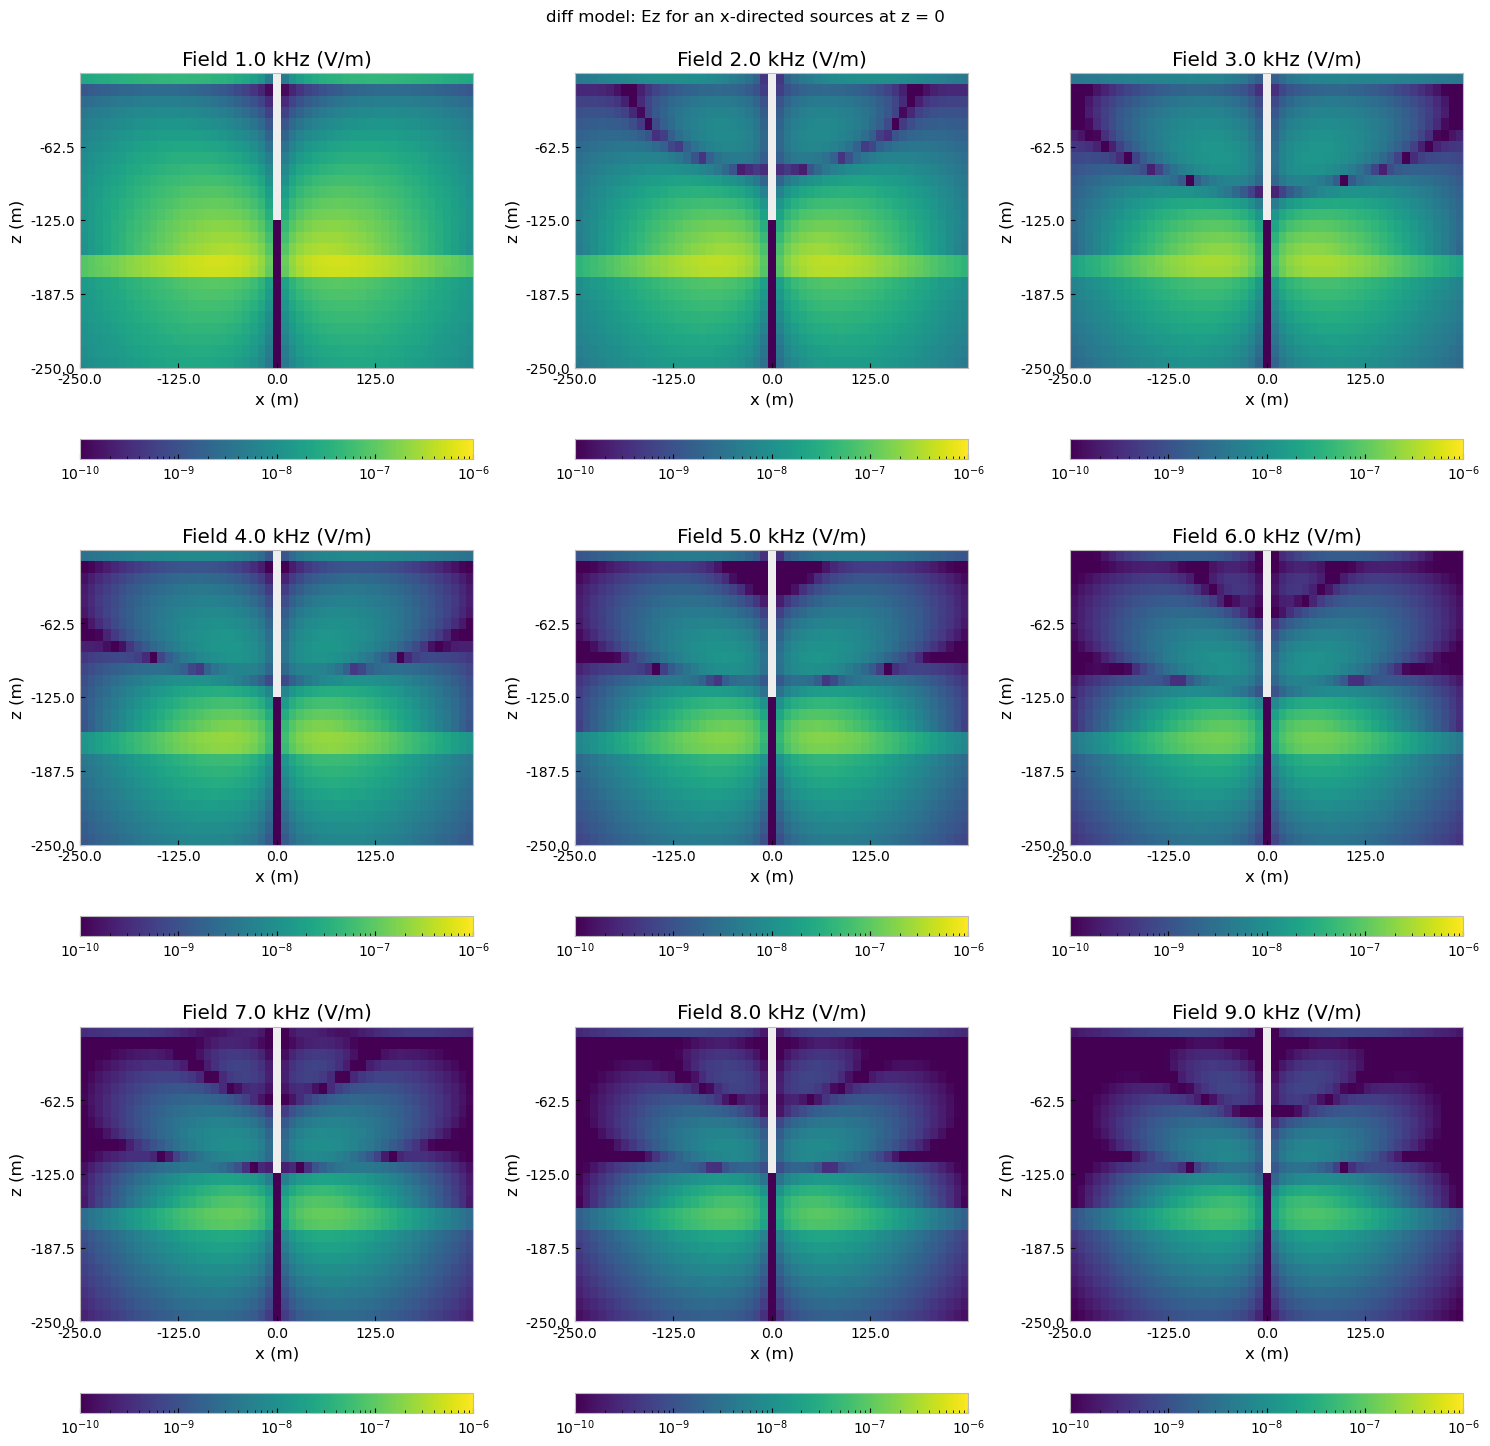

In [570]:
keys = list(emp_solution.keys())
efields = []
efields_base = []
#contour_levels = []

for i in np.arange(len(keys)):
    efields.append(np.transpose(emp_solution[keys[i]]))
    efields_base.append(np.transpose(base_solutions3[keys[i]])) #used for relative differences
    #contour_levels.append(float(np.max(efields[i][2:])/np.e))

names = []
for i in np.arange(len(frequencies)):
    names.append(str(frequencies[i]/1000)+' kHz')
title = to_plot+' model: '+component+' for an x-directed sources at z = 0'

manual_xz_slice_9x(title, efields, names = names, iz = 0, xmin=np.min(x), xmax=np.max(x), zmin=-np.max(z), zmax=-np.min(z), vmin = 1e-10, vmax = 1e-6)

In [551]:
print(np.shape(efields[0]))

(26, 51)


In [571]:
# Define receiver lines to plot

rec_xs = np.array([50, 150, 250]) #Must have length 3
rec_ixs = (rec_xs-np.min(x))/(x[1]-x[0])
print(rec_ixs)

base_rec_lines_x9 = []
rec_lines_x9 = []
labels = []
labels_x9 = []
for i in np.arange(len(efields)):
    efield = efields[i]
    base_efield = efields_base[i]
    print(efield[0,0], base_efield[0,0])
    rec_lines = []
    base_rec_lines = []
    labels = []
    for j in np.arange(len(rec_ixs)):
        rec_line = efield[:,int(rec_ixs[j])]
        base_rec_line = base_efield[:,int(rec_ixs[j])]
        #print(rec_line[0])
        rec_lines.append(rec_line)
        base_rec_lines.append(base_rec_line)
        labels.append(str(frequencies[i]/1000)+' kHz at: '+str(rec_xs[j])+' m')
    rec_lines_x9.append(rec_lines)
    base_rec_lines_x9.append(base_rec_lines)
    labels_x9.append(labels)
    

[30. 40. 50.]
(2.4724270378810608e-08+0j) (2.1446797058920053e-06+0j)
(4.014330230024057e-09+0j) (2.310302509006521e-06+0j)
(-3.8198696480651644e-09+0j) (2.5889565385512124e-06+0j)
(-3.089897642754971e-09+0j) (2.86877765955922e-06+0j)
(-1.115466462046166e-09+0j) (3.1392990913942302e-06+0j)
(-1.152577011365817e-11+0j) (3.3977152471767377e-06+0j)
(3.1703474497308027e-10+0j) (3.6432931984091326e-06+0j)
(2.920337125419302e-10+0j) (3.876437680973202e-06+0j)
(1.7743595173215395e-10+0j) (4.098154748375959e-06+0j)


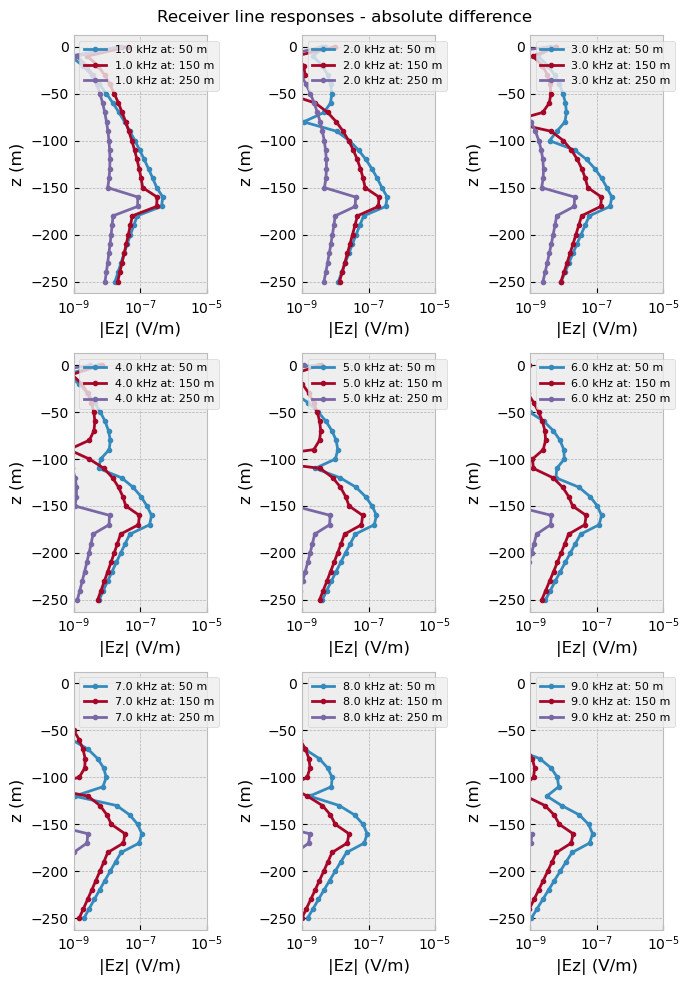

In [572]:
# Plot receiver line responses

fig, ((ax1, ax2, ax3), (ax4, ax5, ax6), (ax7, ax8, ax9)) = plt.subplots(3,3, figsize=(7,10), tight_layout=True)
fig.suptitle('Receiver line responses - absolute difference')
axes = [ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9]

for i in np.arange(len(axes)):
    ax = axes[i]
    rec_lines = rec_lines_x9[i]
    base_rec_lines = base_rec_lines_x9[i]
    labels = labels_x9[i]
    for j in np.arange(len(rec_ixs)):
        #ax.plot(np.abs(np.array(rec_lines[j])/np.array(base_rec_lines[j])), -z, markersize = 3, marker='o', c = 'C'+str(j), label = labels[j])
        ax.plot(np.abs(np.array(rec_lines[j])), -z, markersize = 3, marker='o', c = 'C'+str(j), label = labels[j])
    ax.set_xscale('log')
    ax.set_xlim([1e-9, 1e-5])
    ax.set_xlabel('|'+component+'| (V/m)')
    ax.set_ylabel('z (m)')
    ax.legend(fontsize=8)

In [ ]:
def manual_xz_slice_9x(title, efields, names = [1,2,3,4,5,6,7,8,9], iz = 0, xmin=-300, xmax=300, zmin=-250, zmax=0, vmin = 1e-8, vmax = 1e-4):

    fig, ((ax1, ax2, ax3), (ax4, ax5, ax6), (ax7, ax8, ax9)) = plt.subplots(3,3, figsize=(15,15), tight_layout=True)
    fig.suptitle(title)
    axes = [ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9]

    sizexy = 6.4
    sizez = 4.8
    
    for i in np.arange(len(efields)):
        ax = axes[i]
        to_plot = np.abs(efields[i]) #Assuming field objects are already the right dimensions
        plot = ax.imshow(to_plot, extent = [0, sizexy, 0, sizez], norm='log', vmin = vmin, vmax = vmax)
        #ax.contour(to_plot, [contour[i]], colors='pink', origin = 'upper', extent = [0, sizexy, 0, sizez])
        ax.set_title('Field '+str(names[i])+' (V/m)')
        ax.grid(False)
        plt.colorbar(plot, location='bottom')
        ax.set_xticks(np.arange(0, sizexy, sizexy/4), np.arange(xmin, xmax, (xmax-xmin)/4))
        ax.set_yticks(np.arange(0, sizez, sizez/4), np.arange(zmin, zmax, (zmax-zmin)/4))
        ax.set_xlabel('x (m)')
        ax.set_ylabel('z (m)')

## 4. Effect of receiver length

In [260]:
#Specify which component of the receivers and which frequency range we want to test for

component = 'Ez'
frequencies = [1000]

if component == 'Ez':
    pab = [31]
elif component == 'Ey':
    pab = [21]
elif component == 'Ex':
    pab = [11]

sources = ['x-dir']

In [261]:
#Create a 1D subsurface model to test with

# Layer boundaries
depth = [0, 150, 170]

# Layer resistivities in Ohm.m
res_base = np.array([1e8, 35, 35, 35]) # incl. air (lower res, because of 3D modelling)
res_anomaly = np.array([1e8, 35, 13, 35])

In [262]:
#Specify domain in which to compute the EM response (x,z plane only

x = np.arange(-250,260,2)
z = np.arange(0, 260,2)

In [272]:
all_solutions4 = {}

for i in np.arange(len(frequencies)):
    freq = frequencies[i]
    ab = pab[0]
    source = sources[0]

    solutions = []
    for res in [res_base, res_anomaly]:

        emp_solution = np.zeros((len(x), len(z)), dtype = complex)
        for m in np.arange(len(z)):
            inp = {
                'src': [0,0,0],
                'rec': [x, [0]*len(x), z[m]],
                'depth': depth,
                'res': res,
                'freqtime': [freq],
                'verb': 0,
            }
            efield = empymod.dipole(ab=ab, **inp).amp()
            emp_solution[:,m] = efield
        solutions.append(emp_solution)
                
    all_solutions4['Base model '+component+' for source: '+source+' and freq: '+str(freq)+' Hz'] = solutions[0]
    all_solutions4['Anomaly model '+component+' for source: '+source+' and freq: '+str(freq)+' Hz'] = solutions[1]
    all_solutions4['Difference '+component+' for source: '+source+' and freq: '+str(freq)+' Hz'] = solutions[1]-solutions[0]

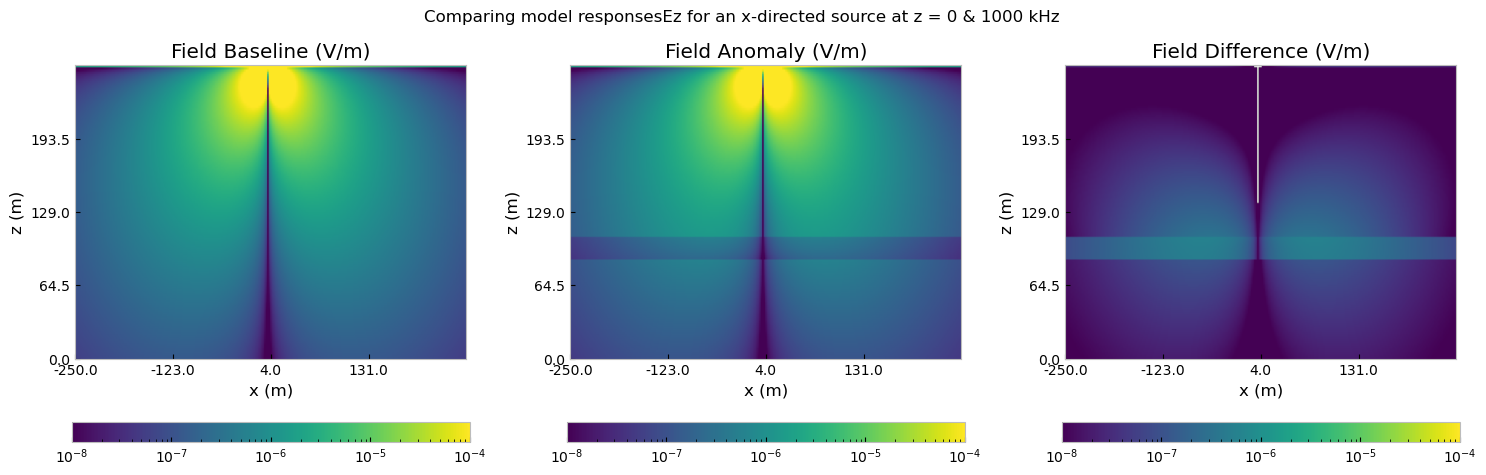

In [274]:
#Plot efields for each simulation

keys = list(all_solutions4.keys())
efields = []
for i in np.arange(len(keys)):
    efields.append(np.transpose(all_solutions4[keys[i]]))

names = ['Baseline', 'Anomaly', 'Difference']
title = 'Comparing model responses'+component+' for an x-directed source at z = 0 & '+str(freq)+' kHz'

manual_xz_slice_3x(title, efields, names = names, iz = 0, xmin=np.min(x), xmax=np.max(x), zmin=np.min(z), zmax=np.max(z), vmin = 1e-8, vmax = 1e-4)

In [282]:
# Define receiver lines to plot

sample_rate = np.arange(1,10)

rec_xs = np.array([50, 150, 250]) #Must have length 3
rec_ixs = (rec_xs-np.min(x))/(x[1]-x[0])
print(rec_ixs)

base_rec_lines_x9 = []
rec_lines_x9 = []
labels = []
labels_x9 = []
for i in np.arange(len(sample_rate)):
    efield = efields[2]
    base_efield = efields[0]
    #print(efield[0,0], base_efield[0,0])
    rec_lines = []
    base_rec_lines = []
    labels = []
    for j in np.arange(len(rec_ixs)):
        rec_line = efield[:,int(rec_ixs[j])]
        base_rec_line = base_efield[:,int(rec_ixs[j])]
        #print(rec_line[0])
        rec_lines.append(rec_line[::sample_rate[i]])
        base_rec_lines.append(base_rec_line[::sample_rate[i]])
        labels.append('1 kHz at: '+str(rec_xs[j])+' m')
    rec_lines_x9.append(rec_lines)
    base_rec_lines_x9.append(base_rec_lines)
    labels_x9.append(labels)

[150. 200. 250.]


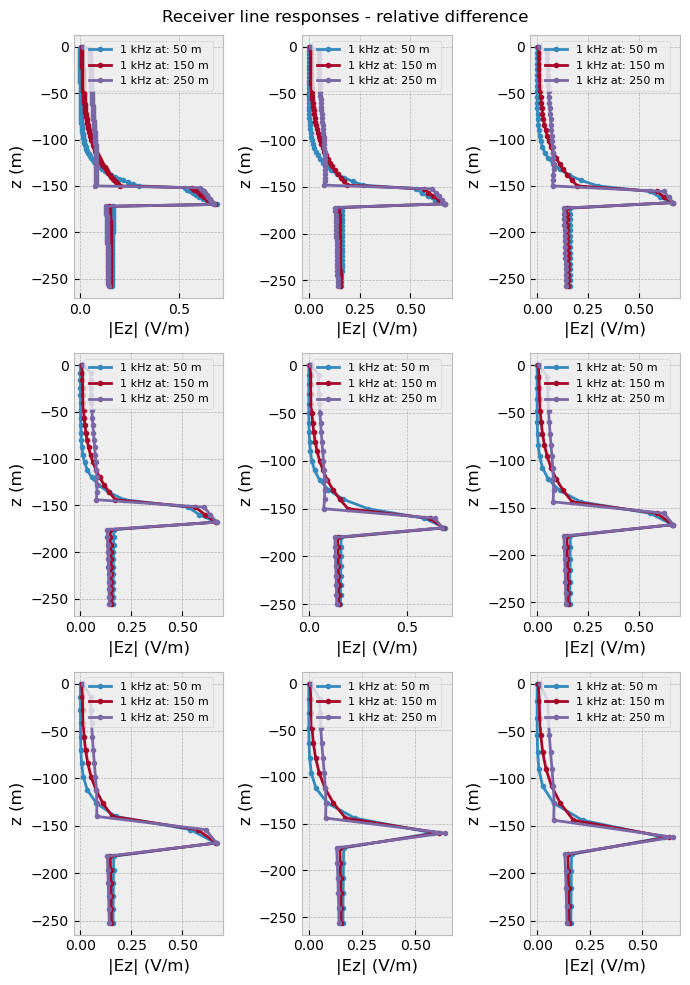

In [288]:
# Plot receiver line responses

fig, ((ax1, ax2, ax3), (ax4, ax5, ax6), (ax7, ax8, ax9)) = plt.subplots(3,3, figsize=(7,10), tight_layout=True)
fig.suptitle('Receiver line responses - relative difference')
axes = [ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9]

for i in np.arange(len(axes)):
    ax = axes[i]
    rec_lines = rec_lines_x9[i]
    base_rec_lines = base_rec_lines_x9[i]
    labels = labels_x9[i]
    for j in np.arange(len(rec_ixs)):
        ax.plot(np.abs(np.array(rec_lines[j])/np.array(base_rec_lines[j])), -z[::sample_rate[i]], markersize = 3, marker='o', c = 'C'+str(j), label = labels[j])
        #ax.plot(np.abs(np.array(rec_lines[j])), -z[::sample_rate[i]], markersize = 3, marker='o', c = 'C'+str(j), label = labels[j])
    #ax.set_xscale('log')
    #ax.set_xlim([1e-10, 5e-7])
    ax.set_xlabel('|'+component+'| (V/m)')
    ax.set_ylabel('z (m)')
    ax.legend(fontsize=8, loc='upper center')

# Tests on complex anomaly models

In [297]:
#Test design

anom_thick = [20, 40, 80]
layer_thick = [0, 5, 10]
anom_res_list = [13, 30, 90]

In [508]:
#Determine survey

component = 'Ex'
frequencies = [1000]

if component == 'Ez':
    pab = [31]
elif component == 'Ey':
    pab = [21]
elif component == 'Ex':
    pab = [11]

sources = ['x-dir']

In [509]:
#Specify domain in which to compute the EM response (x,z plane only

x = np.arange(-250,260,5)
z = np.arange(0, 260,5)

In [510]:
#Define resistivity models

# Layer boundaries
depth = [0]

# Layer resistivities in Ohm.m
res_base = np.array([1e8, 35]) # incl. air (lower res, because of 3D modelling)

models = [res_base]
depths = [depth]

names = ['uniform model']
for i in np.arange(len(anom_thick)):
    for j in np.arange(len(layer_thick)):
        offset = int(anom_thick[i]/2)
        offset_lay = int(layer_thick[j]/2)
        depth = [0, 150-offset,150-offset_lay, 150+offset_lay, 150+offset]
        res_anom = np.array([1e8, 35, 13, 35, 13, 35])
        depths.append(depth)
        models.append(res_anom)
        names.append(str(anom_thick[i])+' ('+str(layer_thick[j])+') m model')

models.append(res_anom) #Not used, Dummy fix

In [511]:
print(len(depths), len(models))
print(depths[0], models[0])
print(len(names))

10 11
[0] [1.0e+08 3.5e+01]
10


In [512]:
all_solutions5 = {}
diff_solutions5 = {}

for i in np.arange(len(anom_res_list)):
    freq = frequencies[0]
    ab = pab[0]
    source = sources[0]
    anom_res = anom_res_list[i]

    solutions = []
    for j in np.arange(len(models)-1): #Neglect the dummy
        
        emp_solution = np.zeros((len(x), len(z)), dtype = complex)
        for m in np.arange(len(z)):
            inp = {
                'src': [0,0,0],
                'rec': [x, [0]*len(x), z[m]],
                'depth': depths[j],
                'res': models[j],
                'freqtime': [freq],
                'verb': 0,
            }
            efield = empymod.dipole(ab=ab, **inp).amp()
            emp_solution[:,m] = efield
        solutions.append(emp_solution)

        #Here we change the anomaly resistivity for the next model to the correct one, leaving the baseline model untouched
        models[j+1][2] = anom_res
        models[j+1][4] = anom_res
                
        all_solutions5[component+' response to '+names[j]+' with '+str(anom_res)+' Ohmm resistivity'] = emp_solution
        diff_solutions5[component+' response to '+names[j]+' with '+str(anom_res)+' Ohmm resistivity'] = emp_solution-solutions[0]



In [513]:
del all_solutions5[component+' response to '+names[0]+' with '+str(anom_res_list[1])+' Ohmm resistivity']
del all_solutions5[component+' response to '+names[0]+' with '+str(anom_res_list[2])+' Ohmm resistivity'] 
del diff_solutions5[component+' response to '+names[0]+' with '+str(anom_res_list[1])+' Ohmm resistivity']
del diff_solutions5[component+' response to '+names[0]+' with '+str(anom_res_list[2])+' Ohmm resistivity'] 

In [514]:
print(list(all_solutions5.keys()))

['Ex response to uniform model with 13 Ohmm resistivity', 'Ex response to 20 (0) m model with 13 Ohmm resistivity', 'Ex response to 20 (5) m model with 13 Ohmm resistivity', 'Ex response to 20 (10) m model with 13 Ohmm resistivity', 'Ex response to 40 (0) m model with 13 Ohmm resistivity', 'Ex response to 40 (5) m model with 13 Ohmm resistivity', 'Ex response to 40 (10) m model with 13 Ohmm resistivity', 'Ex response to 80 (0) m model with 13 Ohmm resistivity', 'Ex response to 80 (5) m model with 13 Ohmm resistivity', 'Ex response to 80 (10) m model with 13 Ohmm resistivity', 'Ex response to 20 (0) m model with 30 Ohmm resistivity', 'Ex response to 20 (5) m model with 30 Ohmm resistivity', 'Ex response to 20 (10) m model with 30 Ohmm resistivity', 'Ex response to 40 (0) m model with 30 Ohmm resistivity', 'Ex response to 40 (5) m model with 30 Ohmm resistivity', 'Ex response to 40 (10) m model with 30 Ohmm resistivity', 'Ex response to 80 (0) m model with 30 Ohmm resistivity', 'Ex respo

In [525]:
# what to plot

to_plot = 'difference'
iar = 2 #Anomaly resistivity index
print('Anomaly resistivity: ', anom_res_list[iar], 'Ohmm, compared to baseline resistivity: ', res_base[1], ' Ohmm')

if to_plot == 'anom response':
    emp_solution = all_solutions5
elif to_plot == 'difference':
    emp_solution = diff_solutions5

Anomaly resistivity:  90 Ohmm, compared to baseline resistivity:  35.0  Ohmm


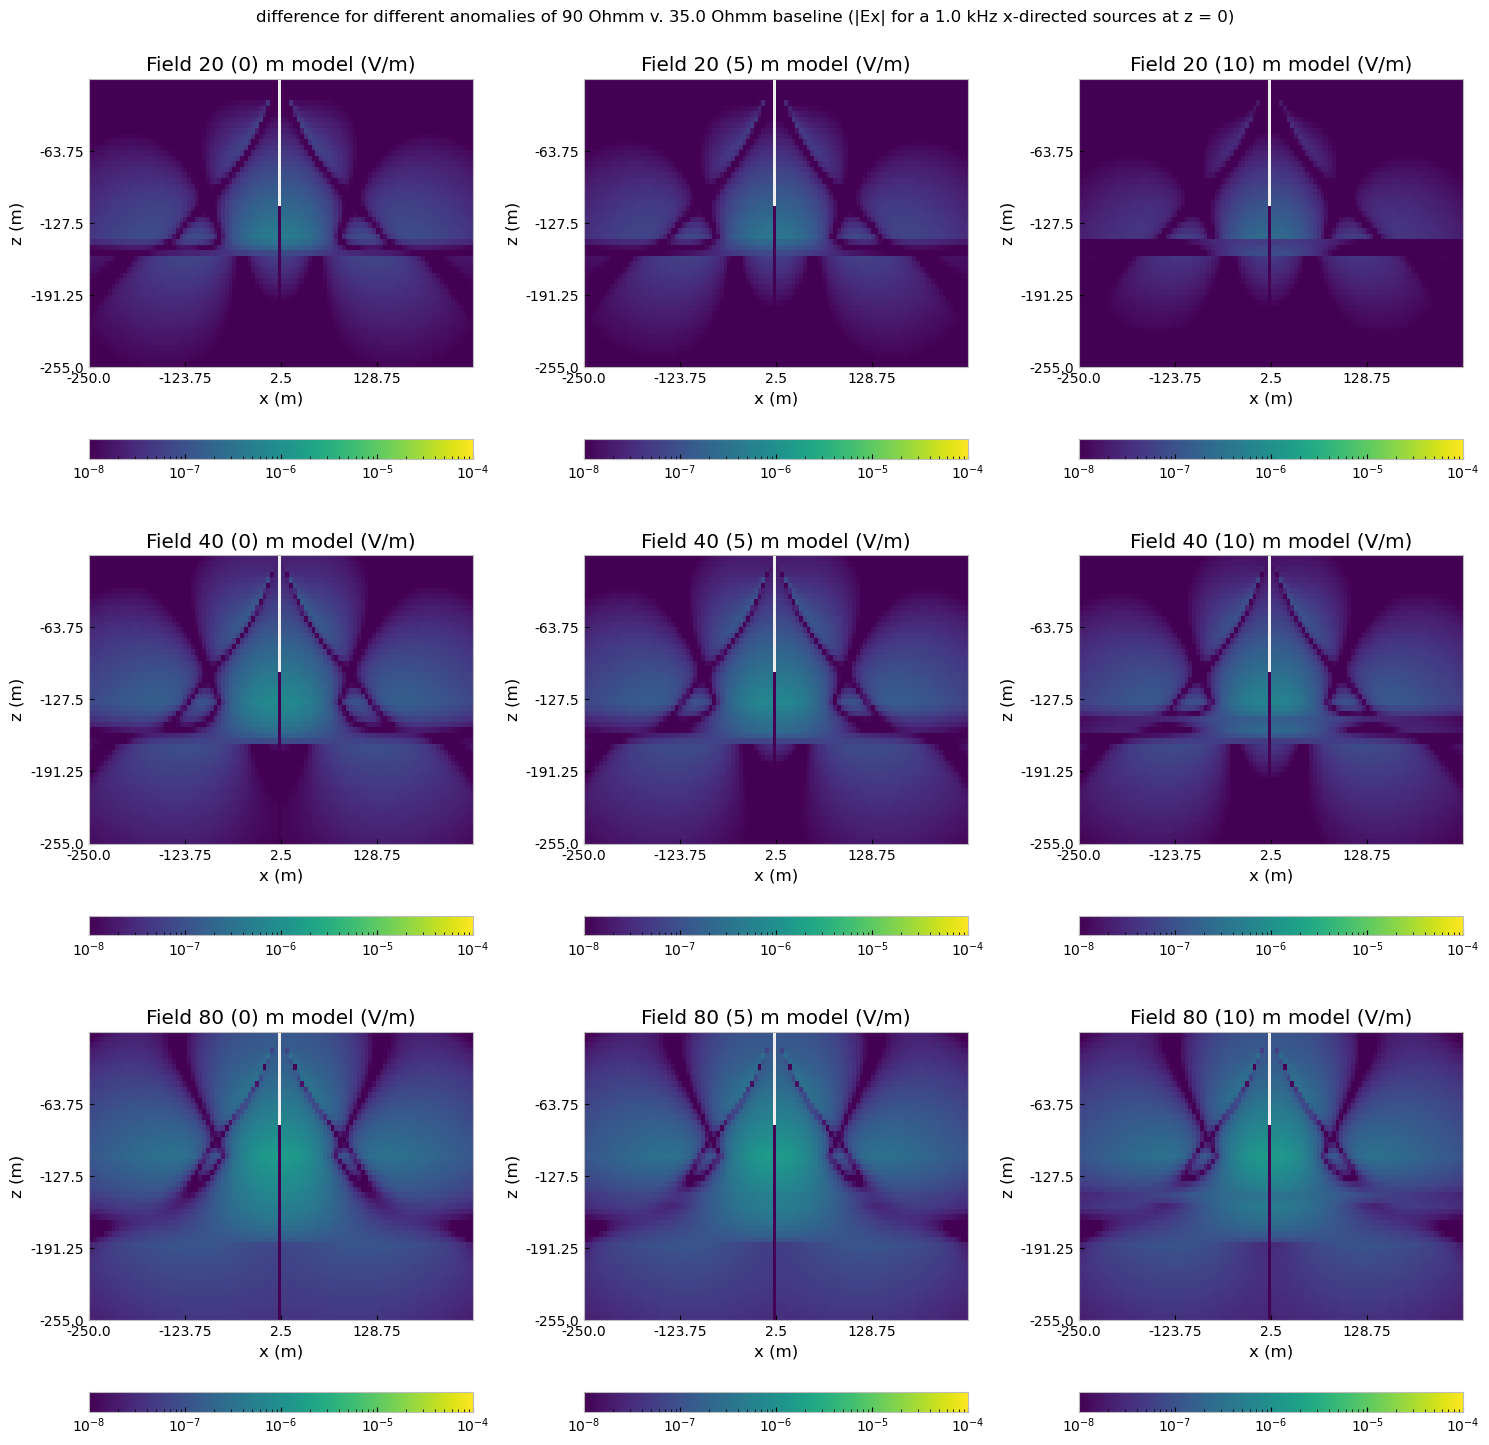

In [526]:
keys = list(emp_solution.keys())
efields = []
efield_base = np.transpose(all_solutions5[keys[0]]) #used for relative differences
#contour_levels = []

nr_anom_models = len(models)-2
for i in np.arange(nr_anom_models):
    efields.append(np.transpose(emp_solution[keys[1+iar*nr_anom_models+i]]))
    #contour_levels.append(float(np.max(efields[i][2:])/np.e))

title = to_plot+' for different anomalies of '+str(anom_res_list[iar])+' Ohmm v. '+str(res_base[1])+' Ohmm baseline (|'+component+'| for a '+str(frequencies[0]/1000)+' kHz x-directed sources at z = 0)'

manual_xz_slice_9x(title, efields, names = names[1:], iz = 0, xmin=np.min(x), xmax=np.max(x), zmin=-np.max(z), zmax=-np.min(z), vmin = 1e-8, vmax = 1e-4)

In [527]:
# Define receiver lines to plot

rec_xs = 150 #Must have length 3
rec_ixs = (rec_xs-np.min(x))/(x[1]-x[0])
print(rec_ixs)


base_rec_lines_x9 = []
rec_lines_x9 = []
labels_x9 = []

nr_anom_models = len(models)-2
for i in np.arange(nr_anom_models):
    rec_lines = []
    base_rec_lines = []
    labels = []
    for j in np.arange(len(anom_res_list)):
        iar = j
        efield = np.transpose(diff_solutions5[keys[1+iar*nr_anom_models+i]])
        base_efield = efield_base
    
        rec_line = efield[:,int(rec_ixs)]
        base_rec_line = base_efield[:,int(rec_ixs)]
        rec_lines.append(rec_line)
        base_rec_lines.append(base_rec_line)
        labels.append('M'+str(i)+', Anom: '+str(anom_res_list[iar])+' Ohmm')
    rec_lines_x9.append(rec_lines)
    base_rec_lines_x9.append(base_rec_lines)
    labels_x9.append(labels)

80.0


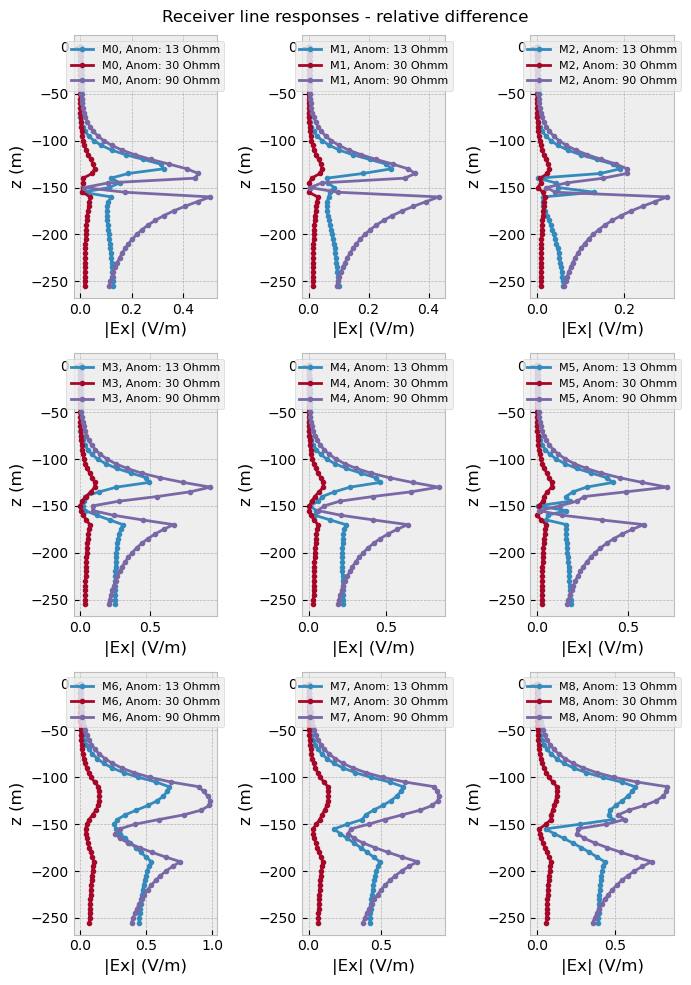

In [528]:
# Plot receiver line responses

fig, ((ax1, ax2, ax3), (ax4, ax5, ax6), (ax7, ax8, ax9)) = plt.subplots(3,3, figsize=(7,10), tight_layout=True)
fig.suptitle('Receiver line responses - relative difference')
axes = [ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9]

for i in np.arange(len(axes)):
    ax = axes[i]
    rec_lines = rec_lines_x9[i]
    base_rec_lines = base_rec_lines_x9[i]
    labels = labels_x9[i]
    for j in np.arange(len(anom_res_list)):
        ax.plot(np.abs(np.array(rec_lines[j])/np.array(base_rec_lines[j])), -z, markersize = 3, marker='o', c = 'C'+str(j), label = labels[j])
        #ax.plot(np.abs(np.array(rec_lines[j])), -z, markersize = 3, marker='o', c = 'C'+str(j), label = labels[j])
    #ax.set_xscale('log')
    #ax.set_xlim([1e-8, 5e-6])
    ax.set_xlabel('|'+component+'| (V/m)')
    ax.set_ylabel('z (m)')
    ax.legend(fontsize=8, loc='upper center')